In [93]:
import pandas as pd
value_system_df = pd.read_csv('2026-02-02_ess_value_system.csv')
value_system_df

,country,P__Universalism__Universalism,P__Universalism__Benevolence,P__Universalism__Tradition,P__Universalism__Conformity,P__Universalism__Security,P__Universalism__Power,P__Universalism__Achievement,P__Universalism__Hedonism,P__Universalism__Stimulation,...,VA__Achievement__lgbt_adopt,VA__Hedonism__immigration,VA__Hedonism__lgbt_freedom,VA__Hedonism__lgbt_adopt,VA__Stimulation__immigration,VA__Stimulation__lgbt_freedom,VA__Stimulation__lgbt_adopt,VA__Self-Direction__immigration,VA__Self-Direction__lgbt_freedom,VA__Self-Direction__lgbt_adopt
0,AT,0.5,0.560350,0.296781,0.277517,0.493449,0.113519,0.260402,0.324114,0.060350,...,-0.028641,0.019490,-0.011192,-0.003466,0.605632,-0.347792,-0.107690,-0.243284,0.139709,0.043259
1,BE,0.5,0.558574,0.374808,0.270656,0.376942,0.058574,0.239303,0.380636,0.193998,...,-0.087920,-0.094143,0.065554,0.037635,0.320609,-0.223247,-0.128167,-0.202117,0.140739,0.080799
2,BG,0.5,0.616116,0.484343,0.430800,0.629903,0.137437,0.452282,0.184087,0.129903,...,-0.057211,0.436852,0.001186,0.188757,0.551861,0.001498,0.238450,0.118366,0.000321,0.051144
3,CH,0.5,0.563144,0.321812,0.181475,0.368729,0.063144,0.196526,0.379109,0.160612,...,-0.056834,-0.125697,0.079617,0.025510,0.359852,-0.227934,-0.073031,-0.374123,0.236973,0.075927
4,CY,0.5,0.530362,0.444315,0.225904,0.529005,0.030362,0.150904,0.149160,0.053230,...,0.139325,0.312418,-0.056618,0.140931,0.508189,-0.092096,0.229243,-0.218342,0.039569,-0.098494
5,CZ,0.5,0.523447,0.368886,0.366486,0.652021,0.239894,0.195749,0.289466,0.152021,...,0.074510,0.196912,-0.066993,0.036753,0.493587,-0.167926,0.092127,-0.298447,0.101536,-0.055705
6,DE,0.5,0.555028,0.325689,0.202032,0.396866,0.055028,0.184108,0.319852,0.132145,...,-0.101028,-0.014926,0.009735,0.005259,0.402200,-0.262320,-0.141715,-0.327713,0.213739,0.115470
7,DK,0.5,0.602999,0.307447,0.352956,0.352181,0.102999,0.201948,0.408895,0.217549,...,-0.131544,-0.127449,0.095295,0.050432,0.297765,-0.222642,-0.117826,-0.259802,0.194256,0.102804
8,EE,0.5,0.524932,0.323268,0.292225,0.464926,0.024932,0.152262,0.235762,0.134699,...,0.101117,0.158790,-0.029985,0.046629,0.383374,-0.072394,0.112578,-0.248783,0.046979,-0.073055
9,ES,0.5,0.527518,0.392539,0.293390,0.450837,0.027518,0.132113,0.275518,0.153560,...,-0.225304,0.092816,-0.063846,-0.050820,0.363833,-0.250271,-0.199209,-0.227940,0.156794,0.124804


## Notes

- "Immigration" means "Immigration bad or good for country's economy", where a higher value means **good**.
- "lgbt_freedom" means "Gay men and lesbians should be free to live life as they wish", where a higher value means **yes**
- "lgbt_adopt" means "Gay men and lesbians should have the same rights to adopt children as straight couples", where a higher value means **yes**

- If no country is specified, plots are over **all** countries

## Step 1: Understand relationship of action judgements
- An action judgement states: If the action is taken, then to what extent will my value be promoted or demoted? (In the opinion of the agent)

### 1.1 See distribution of value preferences over all countries

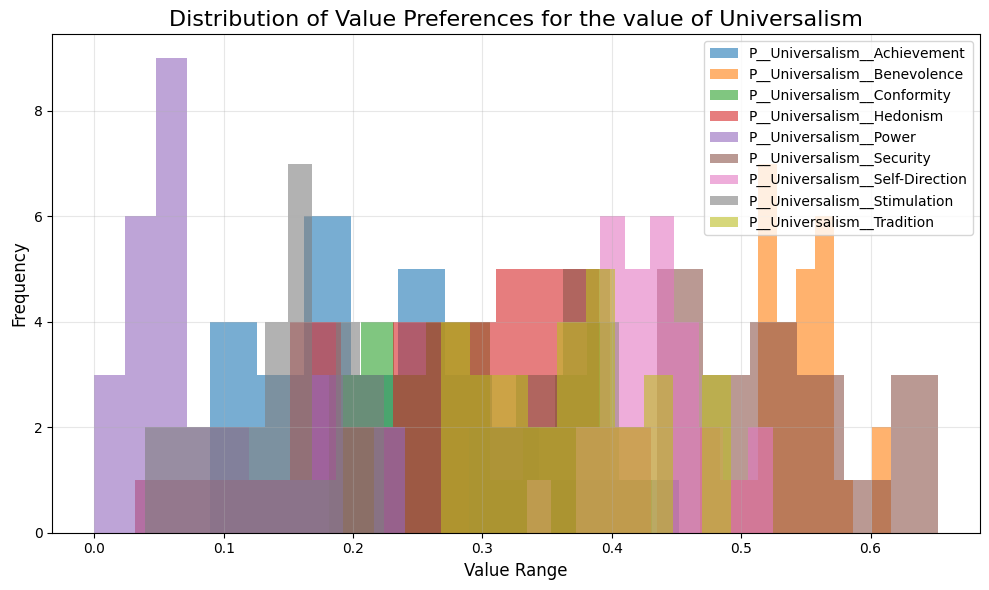

In [94]:
import matplotlib.pyplot as plt

selected_columns = [
    "P__Universalism__Achievement",
    "P__Universalism__Benevolence",
    "P__Universalism__Conformity",
    "P__Universalism__Hedonism",
    "P__Universalism__Power",
    "P__Universalism__Security",
    "P__Universalism__Self-Direction",
    "P__Universalism__Stimulation",
    "P__Universalism__Tradition",
#    "P__Universalism__Universalism",
]
plt.figure(figsize=(10, 6))
for col in selected_columns:
    plt.hist(value_system_df[col], bins=10, alpha=0.6, label=col)
plt.title('Distribution of Value Preferences for the value of Universalism', fontsize=16)
plt.xlabel('Value Range', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.2 See distribution of action judgements for all countries

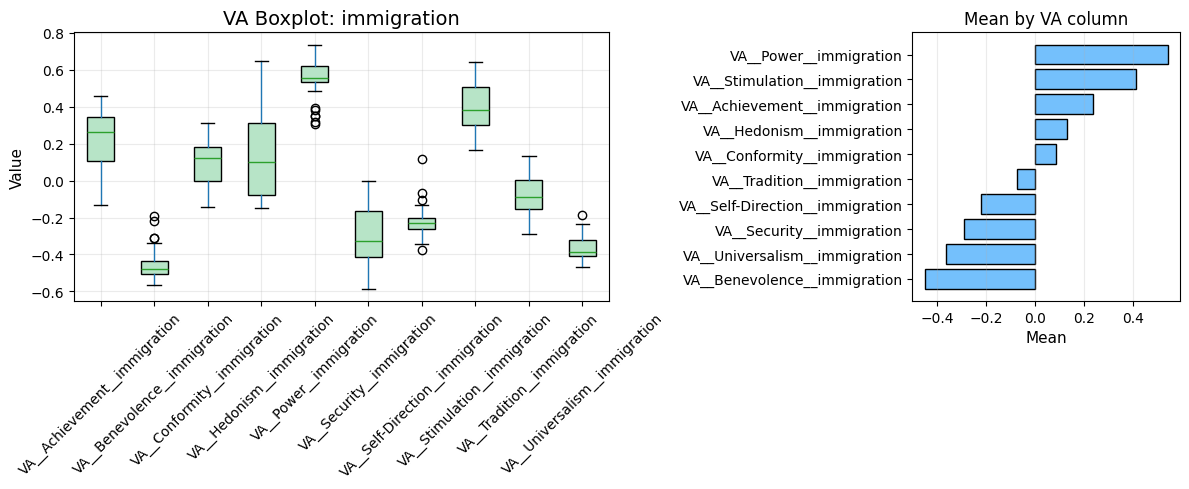

In [95]:
import re
import matplotlib.pyplot as plt

def _va_cols_for_topic(df, topic: str):
    # Get all VA columns for a given topic
    pattern = re.compile(rf"^VA__.*__{re.escape(topic)}$", flags=re.IGNORECASE)
    return [c for c in df.columns if pattern.match(c)]

def plot_va_topic(df, topic: str, figsize=(12, 5)):
    # Plot VA boxplot and mean by VA column for a given topic
    cols = _va_cols_for_topic(df, topic)
    if not cols:
        raise ValueError(f"No VA columns found for topic '{topic}'. Expected columns like 'VA__<Value>__{topic}'.")
    cols = sorted(cols)

    fig, axes = plt.subplots(1, 2, figsize=figsize, gridspec_kw={"width_ratios": [2, 1]})

    df[cols].boxplot(ax=axes[0], patch_artist=True, boxprops=dict(facecolor="#b7e4c7"))
    axes[0].set_title(f"VA Boxplot: {topic}", fontsize=14)
    axes[0].set_ylabel("Value", fontsize=11)
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].grid(alpha=0.25)

    means = df[cols].mean(numeric_only=True).sort_values(ascending=False)
    axes[1].barh(means.index, means.values, color="#74c0fc", edgecolor="black")
    axes[1].set_title("Mean by VA column", fontsize=12)
    axes[1].set_xlabel("Mean", fontsize=11)
    axes[1].invert_yaxis()
    axes[1].grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

plot_va_topic(value_system_df, "immigration")

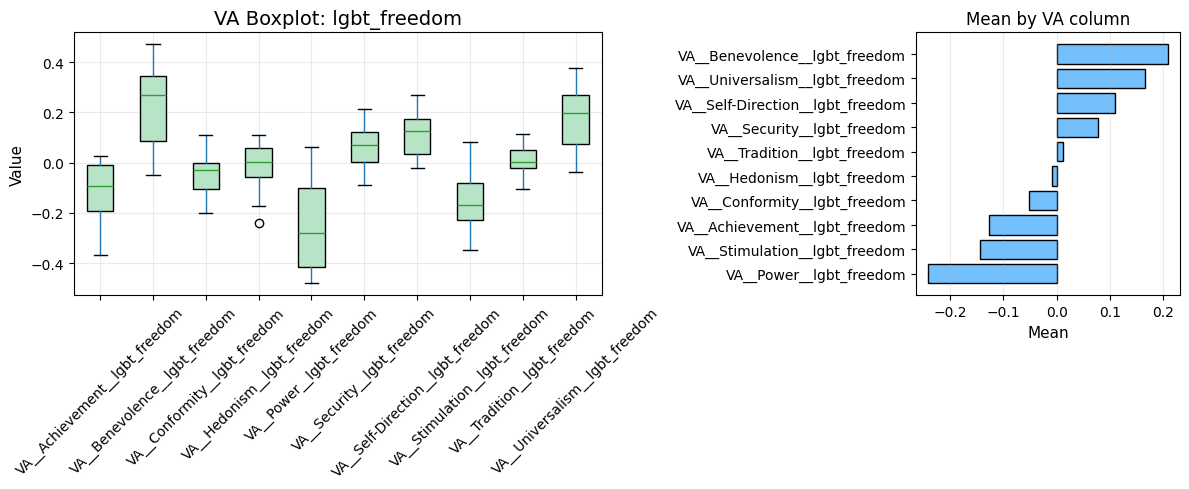

In [96]:
plot_va_topic(value_system_df, "lgbt_freedom")

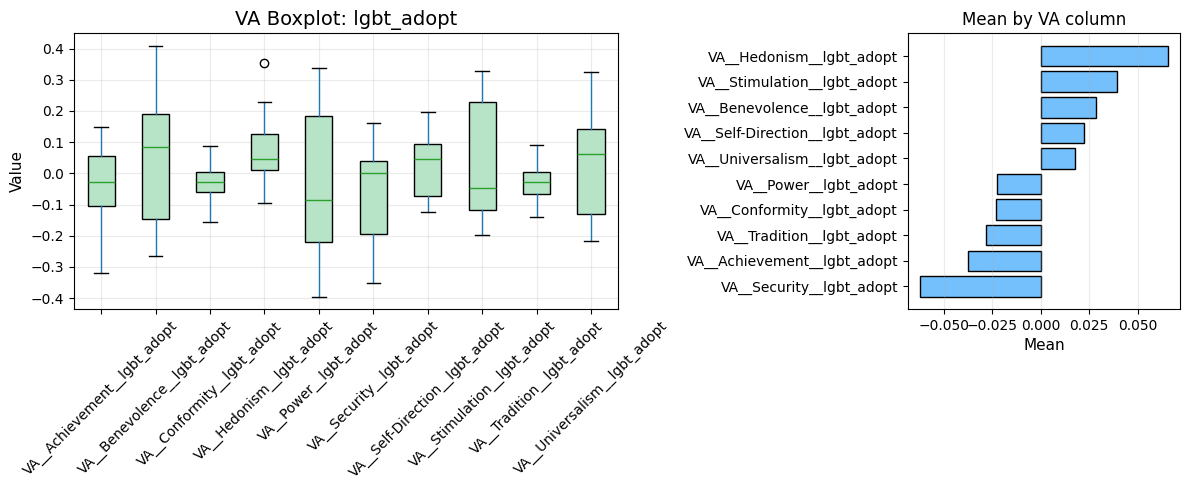

In [97]:
plot_va_topic(value_system_df, "lgbt_adopt")


## Step 2: Understand the polarisation/strength of actions
- To what extent are the actions polarising? Polarising actions have very strong, differing promotion and demotion between agents
- To what extent are the actions strong? Strong actions have very strong promotion and demotion in agents

### 2.1 Define polarising/strength and plot the strongest and most polarising actions

In [98]:
import re
import numpy as np
import pandas as pd

def _cols_by_prefix(df, prefix: str):
    """Get all columns with a given prefix"""
    return [c for c in df.columns if c.startswith(prefix)]

def _p_offdiag_cols(df):
    """Get all off-diagonal P columns"""
    p_cols = _cols_by_prefix(df, "P__")
    off = []
    for c in p_cols:
        parts = c.split("__")
        if len(parts) >= 3:
            vi, vj = parts[1], parts[2]
            if vi != vj:
                off.append(c)
    return sorted(off)


def _va_cols(df):
    return sorted(_cols_by_prefix(df, "VA__"))

P_OFF = _p_offdiag_cols(value_system_df)
VA_COLS = _va_cols(value_system_df)

# Convert to pandas dataframe
country_metrics = pd.DataFrame({"country": value_system_df["country"]}).copy()

P = value_system_df[P_OFF].astype(float)
VA = value_system_df[VA_COLS].astype(float)

country_metrics["P_strength_mean_abs_dev"] = (P - 0.5).abs().mean(axis=1)
country_metrics["P_polarisation_std"] = P.std(axis=1)
country_metrics["P_polarisation_iqr"] = (P.quantile(0.75, axis=1) - P.quantile(0.25, axis=1))

country_metrics["VA_strength_mean_abs"] = VA.abs().mean(axis=1)
country_metrics["VA_polarisation_std"] = VA.std(axis=1)
country_metrics["VA_polarisation_iqr"] = (VA.quantile(0.75, axis=1) - VA.quantile(0.25, axis=1))

country_metrics["overall_strength"] = (
                                              country_metrics["P_strength_mean_abs_dev"].rank(pct=True) +
                                              country_metrics["VA_strength_mean_abs"].rank(pct=True)
                                      ) / 2.0

country_metrics["overall_polarisation"] = (
                                                  country_metrics["P_polarisation_std"].rank(pct=True) +
                                                  country_metrics["VA_polarisation_std"].rank(pct=True)
                                          ) / 2.0

country_metrics = country_metrics.sort_values("overall_strength", ascending=False).reset_index(drop=True)
country_metrics.head(10)

,country,P_strength_mean_abs_dev,P_polarisation_std,P_polarisation_iqr,VA_strength_mean_abs,VA_polarisation_std,VA_polarisation_iqr,overall_strength,overall_polarisation
0,CY,0.236626,0.285331,0.496705,0.200245,0.253625,0.309762,0.862069,0.844828
1,ES,0.202084,0.241241,0.320638,0.233252,0.279621,0.421017,0.810345,0.793103
2,SE,0.203182,0.240490,0.390665,0.221042,0.284945,0.431751,0.810345,0.775862
3,PL,0.212100,0.256131,0.318743,0.194699,0.257452,0.228316,0.775862,0.810345
4,LV,0.210361,0.251341,0.419121,0.185914,0.241723,0.273351,0.706897,0.655172
5,FR,0.200933,0.240972,0.339069,0.218014,0.271246,0.323046,0.706897,0.758621
6,IE,0.200135,0.238663,0.386461,0.218270,0.260287,0.361896,0.689655,0.672414
7,IS,0.193826,0.229552,0.349834,0.239977,0.297521,0.363808,0.672414,0.655172
8,DE,0.201063,0.237383,0.357378,0.201712,0.257228,0.358439,0.672414,0.603448
9,RS,0.215219,0.256705,0.392872,0.164571,0.234450,0.156009,0.637931,0.655172


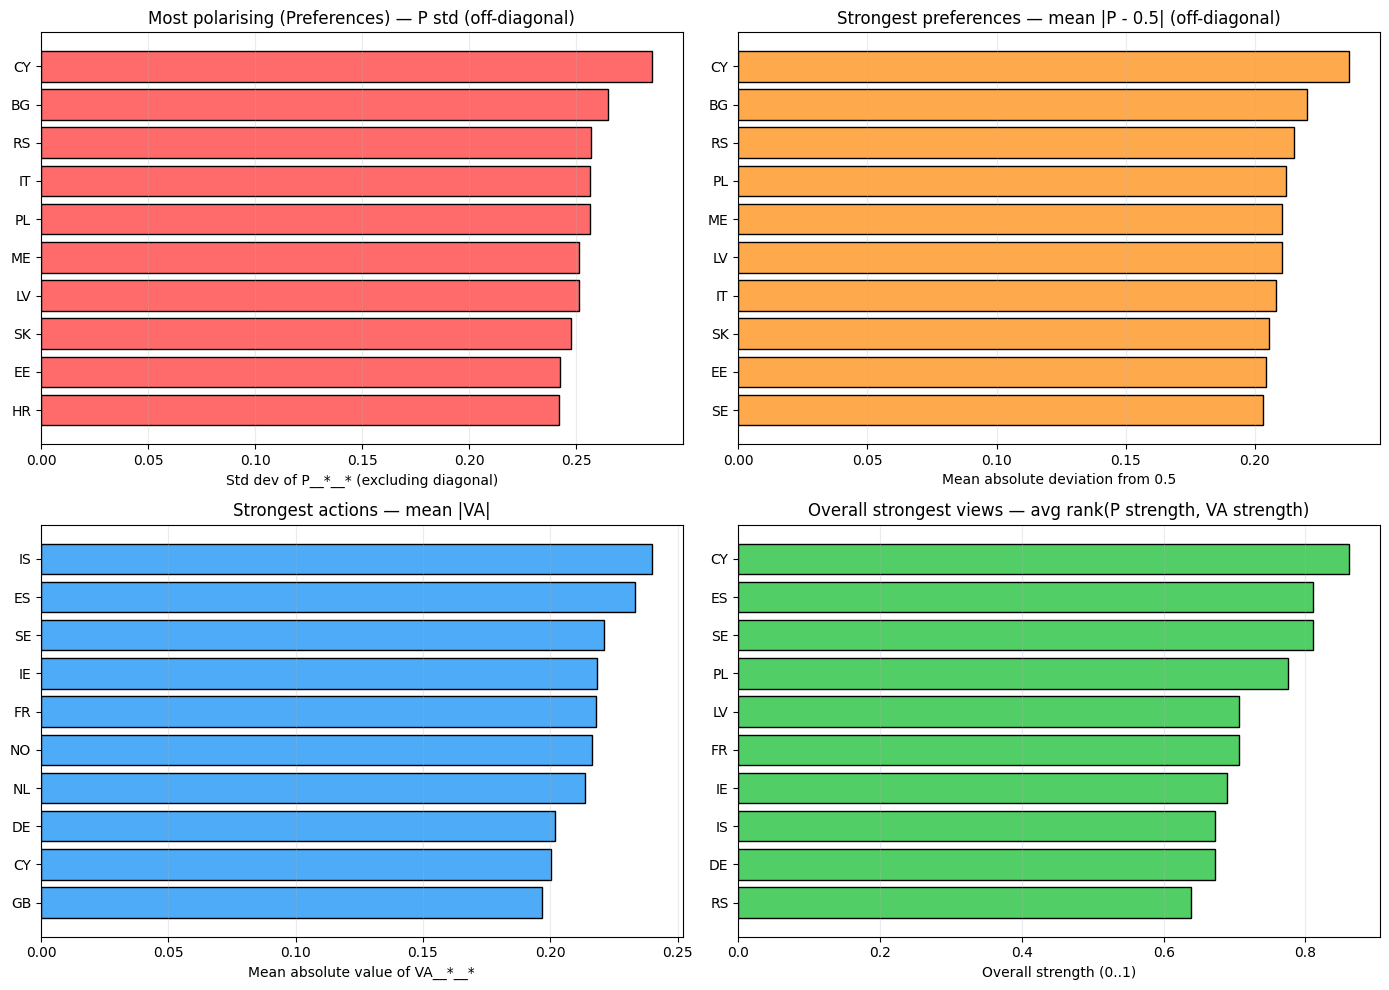

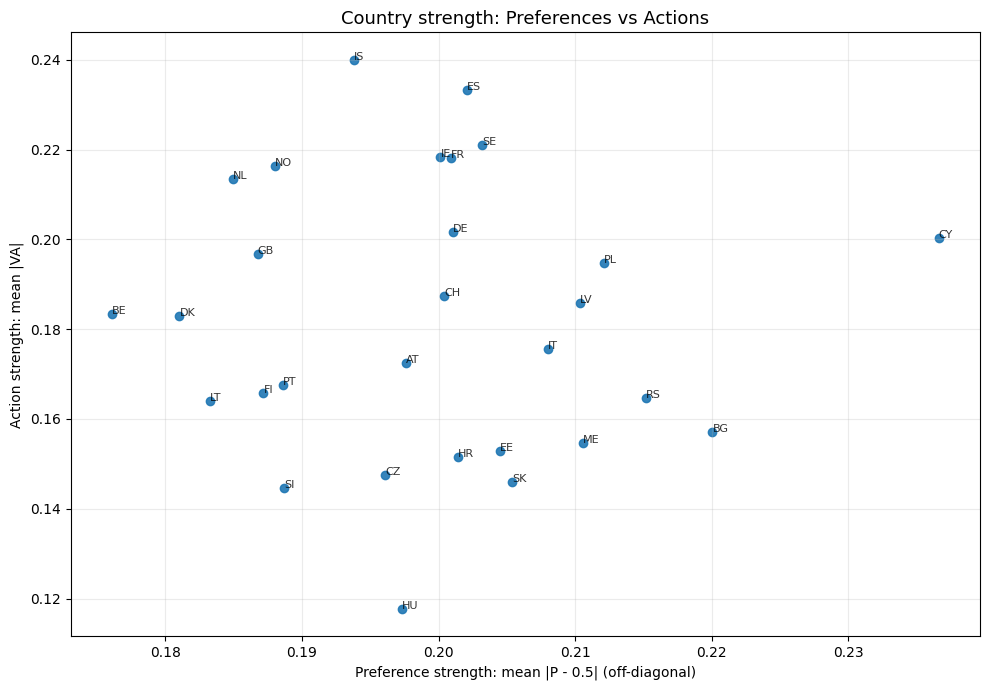

In [104]:
import matplotlib.pyplot as plt

def _topn(df, col, n=10, ascending=False):
    return df.sort_values(col, ascending=ascending).head(n)

top_pol = _topn(country_metrics, "P_polarisation_std", n=10, ascending=False)
top_p_strength = _topn(country_metrics, "P_strength_mean_abs_dev", n=10, ascending=False)
top_va_strength = _topn(country_metrics, "VA_strength_mean_abs", n=10, ascending=False)
top_overall = _topn(country_metrics, "overall_strength", n=10, ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].barh(top_pol["country"][::-1], top_pol["P_polarisation_std"][::-1], color="#ff6b6b", edgecolor="black")
axes[0, 0].set_title("Most polarising (Preferences) — P std (off-diagonal)", fontsize=12)
axes[0, 0].set_xlabel("Std dev of P__*__* (excluding diagonal)")

axes[0, 1].barh(top_p_strength["country"][::-1], top_p_strength["P_strength_mean_abs_dev"][::-1], color="#ffa94d",
                edgecolor="black")
axes[0, 1].set_title("Strongest preferences — mean |P - 0.5| (off-diagonal)", fontsize=12)
axes[0, 1].set_xlabel("Mean absolute deviation from 0.5")

axes[1, 0].barh(top_va_strength["country"][::-1], top_va_strength["VA_strength_mean_abs"][::-1], color="#4dabf7",
                edgecolor="black")
axes[1, 0].set_title("Strongest actions — mean |VA|", fontsize=12)
axes[1, 0].set_xlabel("Mean absolute value of VA__*__*")

axes[1, 1].barh(top_overall["country"][::-1], top_overall["overall_strength"][::-1], color="#51cf66", edgecolor="black")
axes[1, 1].set_title("Overall strongest views — avg rank(P strength, VA strength)", fontsize=12)
axes[1, 1].set_xlabel("Overall strength (0..1)")

for ax in axes.ravel():
    ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
plt.scatter(country_metrics["P_strength_mean_abs_dev"], country_metrics["VA_strength_mean_abs"], alpha=0.9)
for _, r in country_metrics.iterrows():
    plt.text(r["P_strength_mean_abs_dev"], r["VA_strength_mean_abs"], r["country"], fontsize=8, alpha=0.8)

plt.title("Country strength: Preferences vs Actions", fontsize=13)
plt.xlabel("Preference strength: mean |P - 0.5| (off-diagonal)")
plt.ylabel("Action strength: mean |VA|")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [100]:
import re
import numpy as np
import pandas as pd

# --- Parse value names and action names from VA columns
va_pat = re.compile(r"^VA__([^_].*?)__(.+)$")
va_cols = [c for c in value_system_df.columns if c.startswith("VA__") and va_pat.match(c)]

values = sorted({va_pat.match(c).group(1) for c in va_cols})
actions = sorted({va_pat.match(c).group(2) for c in va_cols})

# --- Build per-country preference strength vector from full P matrix
def _p_col(vi, vj):
    return f"P__{vi}__{vj}"

missing_p = [(_p_col(vi, vj)) for vi in values for vj in values if _p_col(vi, vj) not in value_system_df.columns]
if missing_p:
    raise ValueError(f"Missing {len(missing_p)} P columns. Example missing: {missing_p[:5]}")

P_full = np.stack(
    [np.stack([value_system_df[_p_col(vi, vj)].astype(float).to_numpy() for vj in values], axis=1) for vi in values],
    axis=1
)  # shape: (n_countries, n_values, n_values)

shifted = 2.0 * (P_full - 0.5)
# zero diagonal per country
idx = np.arange(len(values))
shifted[:, idx, idx] = 0.0

denom = max(len(values) - 1, 1)
pref_strength = shifted.sum(axis=2) / float(denom)  # shape: (n_countries, n_values)
pref_strength = np.clip(pref_strength, -1.0, 1.0)

pref_strength_df = pd.DataFrame(pref_strength, columns=[f"strength__{v}" for v in values])
pref_strength_df.insert(0, "country", value_system_df["country"].values)

# --- Build VA tensor aligned to (country, value, action)
VA_tensor = np.full((len(value_system_df), len(values), len(actions)), np.nan, dtype=float)

for vi_i, vi in enumerate(values):
    for a_i, a in enumerate(actions):
        col = f"VA__{vi}__{a}"
        if col in value_system_df.columns:
            VA_tensor[:, vi_i, a_i] = value_system_df[col].astype(float).to_numpy()

# --- Decision scores: score(country, action) = sum_v strength[v] * VA[v, action]
scores = np.einsum("cv,cva->ca", pref_strength, VA_tensor)

action_scores = pd.DataFrame(scores, columns=[f"score__{a}" for a in actions])
action_scores.insert(0, "country", value_system_df["country"].values)

# handy long form too
action_scores_long = action_scores.melt(id_vars=["country"], var_name="action", value_name="score")
action_scores_long["action"] = action_scores_long["action"].str.replace(r"^score__", "", regex=True)

action_scores.head()

,country,score__immigration,score__lgbt_adopt,score__lgbt_freedom
0,AT,1.232248,-0.219111,-0.707633
1,BE,0.992588,-0.396800,-0.691162
2,BG,1.472519,0.636251,0.003997
3,CH,1.246159,-0.252905,-0.789328
4,CY,1.643011,0.741160,-0.297753


In [101]:

TOPN = 10

summary = {}
for a in actions:
    col = f"score__{a}"
    df = action_scores[["country", col]].dropna().rename(columns={col: "score"})
    df["abs_score"] = df["score"].abs()
    summary[a] = {
        "top_abs": df.sort_values("abs_score", ascending=False).head(TOPN).drop(columns=["abs_score"]),
        "top_pos": df.sort_values("score", ascending=False).head(TOPN).drop(columns=["abs_score"]),
        "top_neg": df.sort_values("score", ascending=True).head(TOPN).drop(columns=["abs_score"]),
    }

# show a compact table: top-|score| country per action
top1 = []
for a in actions:
    t = summary[a]["top_abs"].iloc[0]
    top1.append({"action": a, "country": t["country"], "score": float(t["score"]), "abs_score": float(abs(t["score"]))})

pd.DataFrame(top1).sort_values("abs_score", ascending=False).reset_index(drop=True)

,action,country,score,abs_score
0,immigration,CY,1.643011,1.643011
1,lgbt_freedom,SE,-0.977169,0.977169
2,lgbt_adopt,IS,-0.837842,0.837842


In [102]:

for a in actions:
    print("\n" + "=" * 80)
    print(f"ACTION: {a}")
    print("- Top by |score|")
    display(summary[a]["top_abs"].reset_index(drop=True))
    print("- Top positive (highest score)")
    display(summary[a]["top_pos"].reset_index(drop=True))
    print("- Top negative (lowest score)")
    display(summary[a]["top_neg"].reset_index(drop=True))


ACTION: immigration
- Top by |score|


,country,score
0,CY,1.643011
1,BG,1.472519
2,IT,1.443618
3,PL,1.441648
4,LV,1.388236
5,RS,1.291497
6,EE,1.288973
7,HR,1.285591
8,ES,1.278903
9,FR,1.276052


- Top positive (highest score)


,country,score
0,CY,1.643011
1,BG,1.472519
2,IT,1.443618
3,PL,1.441648
4,LV,1.388236
5,RS,1.291497
6,EE,1.288973
7,HR,1.285591
8,ES,1.278903
9,FR,1.276052


- Top negative (lowest score)


...

,country,score
0,SE,-0.977169
1,FR,-0.965870
2,IS,-0.964207
3,ES,-0.879725
4,NO,-0.854735
5,NL,-0.838375
6,IE,-0.828683
7,DE,-0.807651
8,CH,-0.789328
9,DK,-0.761671


- Top positive (highest score)


,country,score
0,LT,0.166792
1,RS,0.144041
2,ME,0.075390
3,HU,0.052382
4,SK,0.035442
5,BG,0.003997
6,EE,-0.243402
7,HR,-0.256199
8,PL,-0.269347
9,CY,-0.297753


- Top negative (lowest score)


,country,score
0,SE,-0.977169
1,FR,-0.965870
2,IS,-0.964207
3,ES,-0.879725
4,NO,-0.854735
5,NL,-0.838375
6,IE,-0.828683
7,DE,-0.807651
8,CH,-0.789328
9,DK,-0.761671


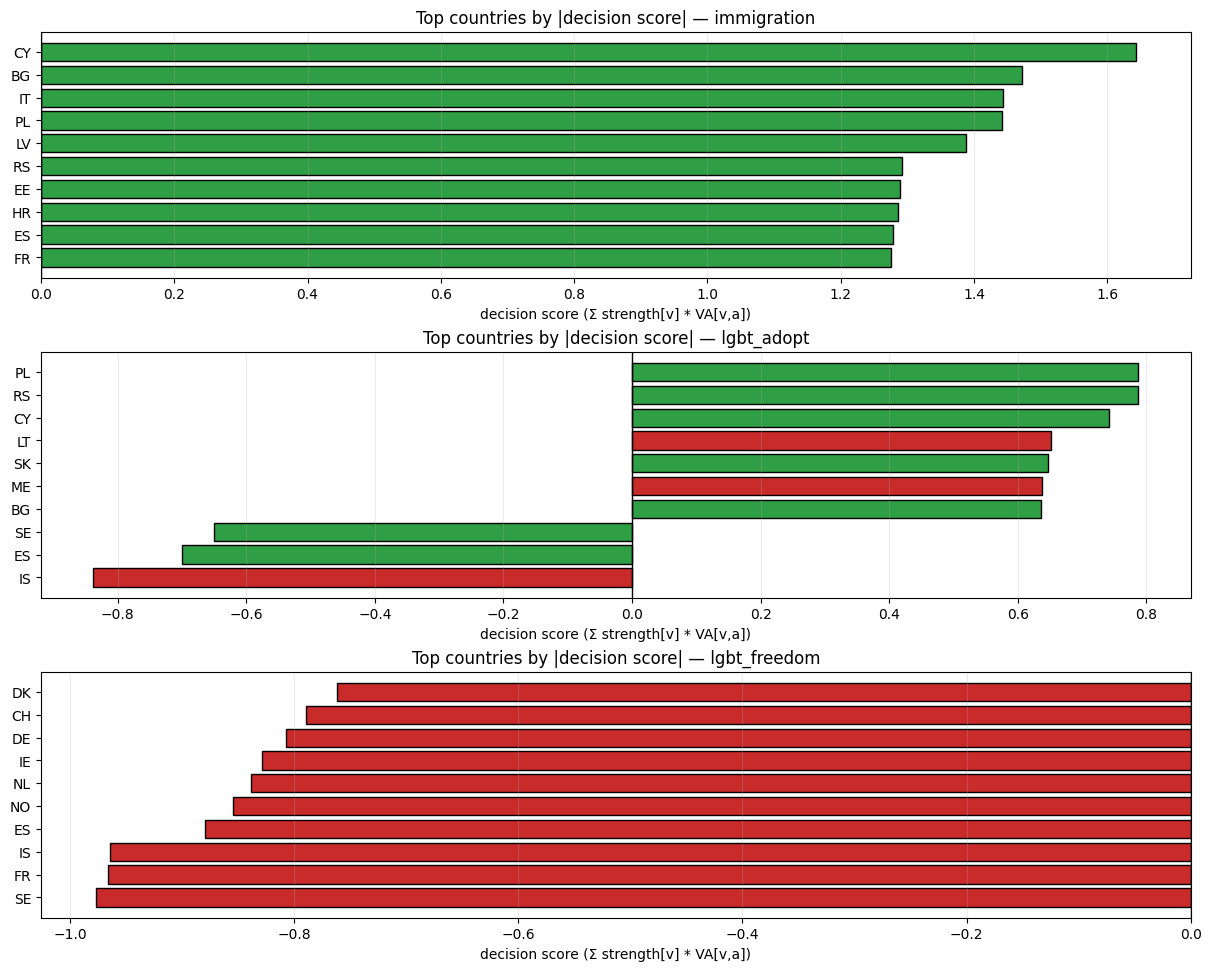

In [103]:
import matplotlib.pyplot as plt

TOPN = 12
n_actions = len(actions)
fig, axes = plt.subplots(n_actions, 1, figsize=(12, 3.2 * n_actions), constrained_layout=True)

if n_actions == 1:
    axes = [axes]

for ax, a in zip(axes, actions):
    df = summary[a]["top_abs"].copy()
    df["sign"] = np.where(df["score"] >= 0, "positive", "negative")
    colors = df["sign"].map({"positive": "#2f9e44", "negative": "#c92a2a"}).to_list()

    df = df.head(TOPN).sort_values("score")
    ax.barh(df["country"], df["score"], color=colors[-len(df):], edgecolor="black")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Top countries by |decision score| — {a}")
    ax.set_xlabel("decision score (Σ strength[v] * VA[v,a])")
    ax.grid(axis="x", alpha=0.25)

plt.show()